In [16]:
%pip install numpy
%pip install matplotlib
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode

In [ ]:
x0 = 0.0
y0 = 0.0

In [ ]:
g = 9.8

In [ ]:
def solve(v0: float, alpha: float, k1: float, k2: float) -> tuple[np.ndarray, np.ndarray]:
    vx0 = v0 * np.cos(alpha)
    vy0 = v0 * np.sin(alpha)

    dt = 0.01
    max_t = 10

    xs = []
    ys = []

    integrator = ode(lambda _, state: np.array([
        state[2], 
        state[3], 
        -k1 * state[2] - k2 * state[2] * np.linalg.norm([state[2], state[3]]), 
        -g - k1 * state[3] - k2 * state[2] * np.linalg.norm([state[2], state[3]])
    ]))
    integrator.set_initial_value(np.array([x0, y0, vx0, vy0]))

    while integrator.successful() and integrator.t < max_t:
        state = integrator.integrate(integrator.t + dt)
        xs.append(state[0])
        ys.append(state[1])

    xs = np.array(xs)
    ys = np.array(ys)

    return (xs, ys)


In [85]:
no_resistance = solve(50, np.pi / 4, 0, 0)
linear_resistance = solve(50, np.pi / 4, 0.01, 0)
quadratic_resistance = solve(50, np.pi / 4, 0, 0.0005)

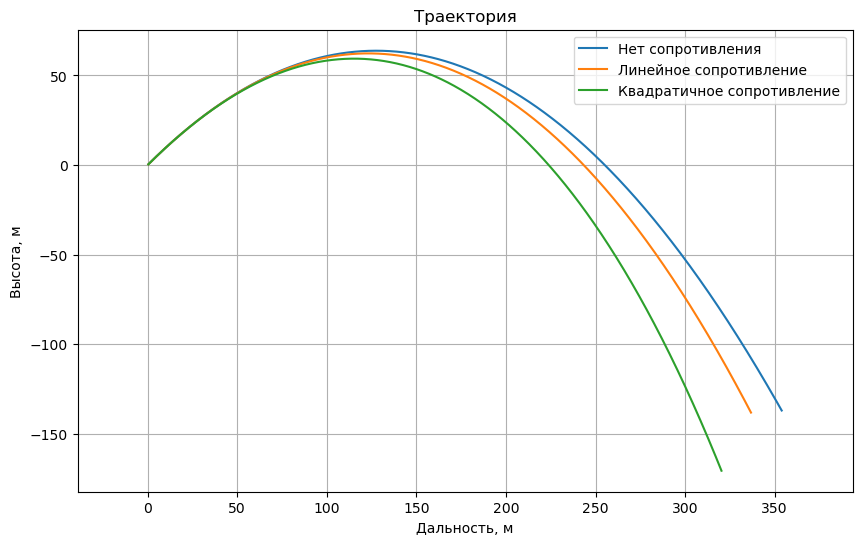

In [87]:
plt.figure(figsize=(10, 6))

plt.plot(no_resistance[0], no_resistance[1], label='Нет сопротивления')
plt.plot(linear_resistance[0], linear_resistance[1], label='Линейное сопротивление')
plt.plot(quadratic_resistance[0], quadratic_resistance[1], label='Квадратичное сопротивление')

plt.title('Траектория')
plt.xlabel('Дальность, м')
plt.ylabel('Высота, м')
plt.legend()
plt.grid(True)
plt.axis('equal') 
plt.show()